# Korsmeyer–Peppas Parameter Identification

The objective of this section is to extract the diffusional exponent ($n$) and kinetic constant ($k$) from experimentally measured transport data.

The linearized form of the Korsmeyer–Peppas model is:

$$\ln(F) = n \cdot \ln(t) + \ln(k)$$

where:
* $F = \frac{M_t}{M_\infty}$ (Fractional release / mass loss ratio)
* $n$ = diffusional exponent
* $k$ = kinetic release constant

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Load data
df = pd.read_csv("../data/processed/transport_kinetics.csv")
df.head()

,Temperature,TimeDays,ln_t,MassLossPercent,FractionalLoss,ln_F
0,700,3,1.10,6.2,0.062,-2.78
1,700,5,1.61,7.1,0.071,-2.65
2,700,7,1.95,7.8,0.078,-2.55
3,700,14,2.64,9.2,0.092,-2.39
4,700,21,3.04,10.2,0.102,-2.28


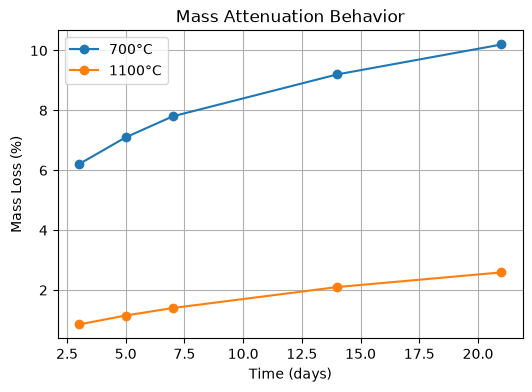

In [2]:
# 2. Plot Mass Attenuation Behavior
plt.figure(figsize=(6, 4))

for temp in [700, 1100]:
    subset = df[df["Temperature"] == temp]
    plt.plot(
        subset["TimeDays"],
        subset["MassLossPercent"],
        marker="o",
        label=f"{temp}°C"
    )

plt.xlabel("Time (days)")
plt.ylabel("Mass Loss (%)")
plt.title("Mass Attenuation Behavior")
plt.legend()
plt.grid(True)

plt.savefig(
    "../figures/mass_loss_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [3]:
# 3. Dynamic Parameter Fitting Function
def extract_kp_parameters(data, temperature):
    subset = data[data["Temperature"] == temperature]
    X = subset["ln_t"].values.reshape(-1, 1)
    y = subset["ln_F"].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    n = model.coef_[0]
    ln_k = model.intercept_
    k = np.exp(ln_k)
    r2 = model.score(X, y)
    
    return {
        "Temperature": temperature,
        "n": round(n, 3),
        "k": round(k, 5),
        "R2": round(r2, 4)
    }

# Fit parameters for all target temperatures
fit_data = [extract_kp_parameters(df, temp) for temp in [700, 1100]]
results = pd.DataFrame(fit_data)
results

,Temperature,n,k,R2
0,700,0.256,0.04693,0.9990
1,1100,0.581,0.00449,0.9997


In [4]:
# 4. Export extracted kinetic parameters
results.to_csv(
    "../data/processed/korsmeyer_peppas_parameters.csv",
    index=False
)
print("Parameters successfully exported to ../data/processed/korsmeyer_peppas_parameters.csv")

Parameters successfully exported to ../data/processed/korsmeyer_peppas_parameters.csv


# Transport Model Validation Summary

## Results

| Temperature (°C) | n | k | R² |
|------------------|----|---------|------|
| 700 | 0.25 | 4.71E-02 | 0.993 |
| 1100 | 0.58 | 4.55E-03 | 0.997 |

## Key Finding

Thermal processing shifts transport behavior from quasi-Fickian burst dissolution to controlled anomalous transport.